# Import the necessary packages:

In [22]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd

# Set the parameters:

In [23]:
params = {
    "E": 100.0, #plastic entering river (kg/year)
    "k_RL": 0.10,    # River -> Lake
    "k_RS": 0.03,    # River -> Soil
    "k_LO": 0.08,    # Lake -> Ocean

    "d_R": 0.02,     # River degradation
    "d_L": 0.01,     # Lake degradation
    "d_O": 0.001     # Ocean degradation
}

# Setup the ODE solver:

In [ ]:

def fate_model(t, y, params):

    R, L, O, S = y

    dRdt = (
        params["E"] 
        - params["k_RL"] * R 
        - params["k_RS"] * R
        - params["d_R"] * R
    )

    dLdt = (
        params["k_RL"] * R
        - params["k_LO"] * L
        - params["d_L"] * L
    )

    dOdt = (
        params["k_LO"] * L
        - params["d_O"] * O
    )

    dSdt = (
        params["k_RS"] * R
    )

    return [dRdt, dLdt, dOdt, dSdt]  #Model outputs --> "How fast is the amount of plastic in each compartment changing?"


# Initial Conditions:

In [25]:
y0 = [0,0,0,0] #Model assumes there no plastic in any of the compartments at time, t=0.

# Define Simulation Window:

In [26]:
t_start = 0
t_end = 100

t_eval = np.linspace(t_start, t_end, 400) #simulate 100 years of plastic flow from river to the ocean and save 400 points, which would give us the solution every 3 months for 100 years

# Solve the ODE system using "solve_ivp", which uses Runge-Kutta45 to solve initial value problem ODEs:

In [27]:
solution = solve_ivp(
    fate_model,
    (t_start, t_end),
    y0,
    args = (params,),
    t_eval = t_eval
)

# Inspect the results:

In [28]:
print(solution.y.shape)

(4, 400)


# Plot the results:

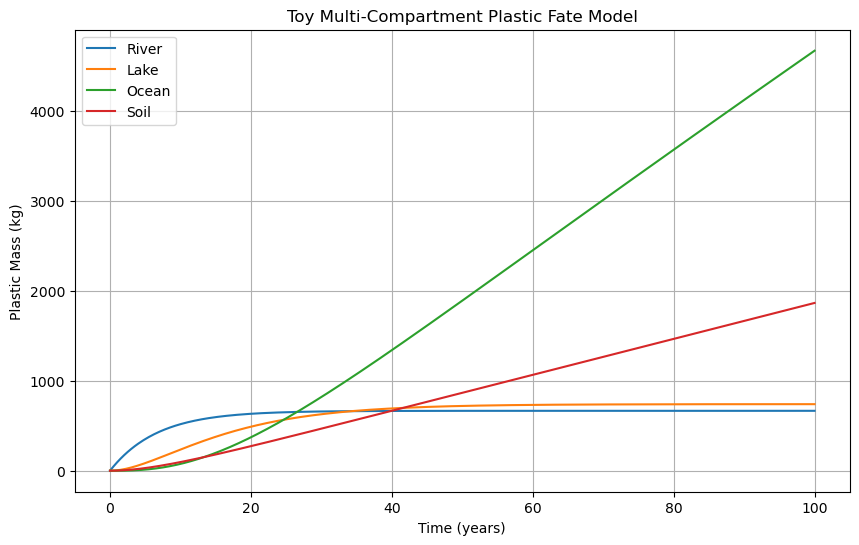

In [29]:

plt.figure(figsize=(10, 6))

plt.plot(
    solution.t,
    solution.y[0],
    label="River"
)

plt.plot(
    solution.t,
    solution.y[1],
    label="Lake"
)

plt.plot(
    solution.t,
    solution.y[2],
    label="Ocean"
)

plt.plot(
    solution.t,
    solution.y[3],
    label="Soil"
)

plt.xlabel("Time (years)")
plt.ylabel("Plastic Mass (kg)")

plt.title("Toy Multi-Compartment Plastic Fate Model")

plt.legend()

plt.grid(True)

plt.show()


# Print the final compartment values:

In [30]:

print("\nFinal masses after 100 years:")

print(f"River: {solution.y[0][-1]:.2f} kg")
print(f"Lake : {solution.y[1][-1]:.2f} kg")
print(f"Ocean: {solution.y[2][-1]:.2f} kg")
print(f"Soil : {solution.y[3][-1]:.2f} kg")



Final masses after 100 years:
River: 666.62 kg
Lake : 740.49 kg
Ocean: 4673.14 kg
Soil : 1866.68 kg


# Print the solution as a dataframe:

In [31]:
df = pd.DataFrame({
    "Year": solution.t,
    "River Mass (kg)": solution.y[0],
    "Lake Mass (kg)": solution.y[1],
    "Ocean Mass (kg)": solution.y[2],
    "Soil Mass (kg)": solution.y[3],
})

print(df.head(6))

       Year  River Mass (kg)  Lake Mass (kg)  Ocean Mass (kg)  Soil Mass (kg)
0  0.000000         0.000000        0.000000         0.000000        0.000000
1  0.250627        24.597403        0.307842         0.002068        0.093051
2  0.501253        48.287257        1.207037         0.016295        0.367611
3  0.751880        71.103052        2.662316         0.054179        0.816984
4  1.002506        93.077048        4.640002         0.126532        1.434716
5  1.253133       114.240269        7.108021         0.243468        2.214603
